In [1]:
import pyspark
from pyspark.sql import SparkSession

spark = (SparkSession.builder 
    .appName("EDA")
    .config("spark.driver.memory", "4g")
    .config("spark.executor.memory", "4g")
    .getOrCreate()
)

print("Spark version:", spark.version)

Spark version: 3.5.0


In [2]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import pandas as pd
pd.set_option('display.max_columns', None)
import plotly.express as px
import plotly.graph_objects as go
path = "/home/jovyan/work/data/bronze/"

Evaluamos la cardinalidad de nuestras variables

In [3]:
fraud_data_df = spark.read.parquet(f"{path}complete_fraud_data_df.parquet")

print(f"Filas: {fraud_data_df.count()}, Columnas: {len(fraud_data_df.columns)}")
fraud_data_df.printSchema()
fraud_data_df.limit(5).toPandas()

Filas: 13305915, Columnas: 40
root
 |-- id: string (nullable = true)
 |-- client_id: string (nullable = true)
 |-- card_id: string (nullable = true)
 |-- mcc: string (nullable = true)
 |-- merchant_city: string (nullable = true)
 |-- merchant_state: string (nullable = true)
 |-- zip: string (nullable = true)
 |-- date: timestamp (nullable = true)
 |-- amount: double (nullable = true)
 |-- use_chip: string (nullable = true)
 |-- merchant_id: integer (nullable = true)
 |-- errors: string (nullable = true)
 |-- merchant_latitude: double (nullable = true)
 |-- merchant_longitude: double (nullable = true)
 |-- mcc_description: string (nullable = true)
 |-- current_age: integer (nullable = true)
 |-- retirement_age: integer (nullable = true)
 |-- birth_year: integer (nullable = true)
 |-- birth_month: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- address: string (nullable = true)
 |-- client_latitude: double (nullable = true)
 |-- client_longitude: double (nullable = t

,id,client_id,card_id,mcc,merchant_city,merchant_state,zip,date,amount,use_chip,merchant_id,errors,merchant_latitude,merchant_longitude,mcc_description,current_age,retirement_age,birth_year,birth_month,gender,address,client_latitude,client_longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web,target
0,10000109,1703,2969,4121,ONLINE,NaN,NaN,2011-08-30 12:14:00,25.88,Online Transaction,18563,None,NaN,NaN,Taxicabs and Limousines,47,65,1972,8,Female,1532 Birch Drive,39.08,-108.55,24115.0,49169.0,65994.0,747,2,Mastercard,Credit,5745606898714105,2022-06-01,753,True,2,10600.0,2008-05-01,2019,False,False
1,10000133,1621,5036,5411,San Diego,CA,92129,2011-08-30 12:18:00,13.29,Swipe Transaction,57414,None,32.9652,-117.1213,"Grocery Stores, Supermarkets",66,69,1953,9,Male,900 Catherine Street,32.96,-117.12,36323.0,74059.0,144396.0,744,4,Visa,Credit,4601495519183808,2012-04-01,833,True,1,17000.0,2005-10-01,2016,False,None
2,10000137,1067,1063,5411,Derby,KS,67037,2011-08-30 12:19:00,10.60,Swipe Transaction,40041,None,37.5530,-97.2549,"Grocery Stores, Supermarkets",76,63,1943,12,Male,343 Lafayette Drive,37.54,-97.25,24531.0,41790.0,24676.0,719,5,Visa,Credit,4690211102957031,2023-06-01,820,False,1,11200.0,2005-02-01,2009,False,False
3,10000175,114,3070,5970,Covina,CA,91723,2011-08-30 12:26:00,46.21,Swipe Transaction,11468,None,34.0860,-117.8843,"Artist Supply Stores, Craft Shops",47,65,1972,12,Female,112 Elm Avenue,34.18,-118.39,16892.0,34441.0,907.0,725,4,Mastercard,Debit,5471501151275219,2019-01-01,875,True,2,16617.0,2010-05-01,2011,False,False
4,10000178,1145,6011,5541,Appleton,WI,54913,2011-08-30 12:26:00,78.00,Swipe Transaction,49789,None,44.3456,-88.4343,Service Stations,43,65,1977,1,Female,7512 South Boulevard,44.26,-88.39,36825.0,75080.0,35268.0,747,3,Mastercard,Debit,5350628456401491,2024-11-01,382,True,1,35169.0,2010-12-01,2012,False,False


In [8]:
col_distinct = []
for col_name in fraud_data_df.columns:
    distinct = fraud_data_df.select(col_name).distinct().count()
    col_distinct.append((col_name, distinct))

col_uniques_df = (pd.DataFrame(col_distinct, columns=["Column_Name", "Unique_Values"])
                     .sort_values(by="Unique_Values", ascending=False)
)

col_uniques_df 

,Column_Name,Unique_Values
0,id,13305915
7,date,4136496
8,amount,81160
10,merchant_id,74831
6,zip,25257
13,merchant_longitude,23897
12,merchant_latitude,22900
4,merchant_city,12492
2,card_id,4071
30,card_number,4071


Eliminamos las variables que no aportan al análisis, por ejemplo la variable "id", es el identificador para cada transaccion y tiene una cardinalidad equivalente al número de filas, en el lado opuesto nos encontramos la variable "card_on_dark_web" que presenta una cardinalidad 1.

In [4]:
fraud_data_df = (
    fraud_data_df
    .drop("id", "mcc", "address", "card_number", "cvv", "card_on_dark_web")
)

In [10]:
client_fraudlabel_df = (
    fraud_data_df
    .select("client_id", "target")
    .groupBy("client_id")
    .agg(
        F.sum(F.when(F.col("target") == True, 1).otherwise(0)).alias("Total")
    )
    .withColumn("client_label", 
        F.when(F.col("Total") > 0, "Fraudulent_Client").otherwise("Legitimate_Client")
    )
)

client_fraudlabel_df.groupBy("client_label").count().show()

+-----------------+-----+
|     client_label|count|
+-----------------+-----+
|Legitimate_Client|   23|
|Fraudulent_Client| 1196|
+-----------------+-----+



Obtenemos un total 1219 clientes de los que 1196 registran mínimo una operación fraudulenta

A continuación seleccioanremos una lista de variables para analizar su cardinalidad, distribución y calidad, esto lo llevaremos a cabo de forma automatizada con la herramienta sweetviz y su resultado lo almacenaremos en un html alojado en la carpeta reportes


In [8]:
EDA_columns = ["amount", "use_chip", "errors", "mcc_description", "target",
    "year_pin_last_changed", "credit_limit", "card_brand", "card_type",
    "current_age", "gender", "per_capita_income", "yearly_income", 
    "total_debt", "credit_score", "num_credit_cards"
]

true_data_pd = (
    fraud_data_df
    .filter(F.col("target") == True)
    .select(EDA_columns)
    .withColumn("target", F.lit(1).cast("tinyint")) 
    .toPandas()

)

false_data_pd = (
    fraud_data_df
    .filter(F.col("target") == False)
    .select(EDA_columns)
    .sample(withReplacement=False, fraction=0.01, seed=777)
    .withColumn("target", F.lit(0).cast("tinyint"))
    .toPandas()
)

sample_data_pd = pd.concat([false_data_pd, true_data_pd], ignore_index=True)

sample_data_pd = sample_data_pd.sample(frac=1, random_state=42).reset_index(drop=True)


In [12]:
sample_data_pd.head(5)_ty

,amount,use_chip,errors,mcc_description,target,year_pin_last_changed,credit_limit,card_brand,card_type,current_age,gender,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
0,30.10,Swipe Transaction,NaN,"Package Stores, Beer, Wine, Liquor",1,2009,7364.0,Mastercard,Debit,54,Male,13093.0,26696.0,0.0,683,5
1,5.48,Swipe Transaction,NaN,Wholesale Clubs,0,2008,17231.0,Visa,Debit,59,Male,16336.0,33311.0,65822.0,590,2
2,45.48,Online Transaction,NaN,Department Stores,1,2011,31490.0,Mastercard,Debit,33,Male,29237.0,59613.0,36199.0,763,4
3,-66.00,Chip Transaction,NaN,Service Stations,0,2009,66.0,Mastercard,Debit (Prepaid),48,Male,46232.0,94260.0,39326.0,815,4
4,95.00,Swipe Transaction,NaN,Miscellaneous Food Stores,0,2009,10843.0,Mastercard,Debit,43,Female,14320.0,29194.0,10895.0,703,2


In [11]:
import sweetviz as sv

report_ml = sv.analyze(
    sample_data_pd,
    target_feat="target"
)

report_ml.show_html(filepath="/home/jovyan/work/reports/EDA_sv_tfm.html", open_browser=False)

                                             |          | [  0%]   00:00 -> (? left)

Report /home/jovyan/work/reports/EDA_sv_tfm.html was generated.


A continuacion analizaremos la demografía de los clientes, en general, ya que apenas 23 de los clientes aportados en el dataset no registran ninguna operación fraudulenta

In [4]:
demographic_df = (
    spark.read.parquet("/home/jovyan/work/data/silver/users_data_df.parquet")
    .select("current_age", "gender")
    .groupBy("current_age", "gender")
    .count()
    .withColumn("count_pyramid", 
        F.when(F.col("gender") == "Male", F.col("count") * -1).otherwise(F.col("count"))
    )
    .orderBy("current_age")
)
demographic_df.show(5)

+-----------+------+-----+-------------+
|current_age|gender|count|count_pyramid|
+-----------+------+-----+-------------+
|         18|  Male|   43|          -43|
|         18|Female|   34|           34|
|         19|  Male|   14|          -14|
|         19|Female|   20|           20|
|         20|  Male|   22|          -22|
+-----------+------+-----+-------------+
only showing top 5 rows



In [5]:
demographic_first_fraud_age_df = (
    fraud_data_df
    .filter(F.col("target") == True)  
    .withColumn("day", F.to_date(F.col("date")))
    .groupBy("client_id", "gender")
    .agg(
        F.min("day").alias("first_fraud_date"),
        (F.min(F.year(F.col("day"))) - F.first("birth_year")).alias("age_at_first_fraud")
    )
    .select("age_at_first_fraud", "gender")
    .groupBy("age_at_first_fraud", "gender")
    .count()
    .withColumn("count_pyramid", 
        F.when(F.col("gender") == "Male", F.col("count") * -1).otherwise(F.col("count"))
    )
    .orderBy("age_at_first_fraud")
)

demographic_first_fraud_age_df.show(5)

+------------------+------+-----+-------------+
|age_at_first_fraud|gender|count|count_pyramid|
+------------------+------+-----+-------------+
|                18|  Male|    1|           -1|
|                18|Female|    1|            1|
|                20|Female|    1|            1|
|                21|Female|    3|            3|
|                21|  Male|    4|           -4|
+------------------+------+-----+-------------+
only showing top 5 rows



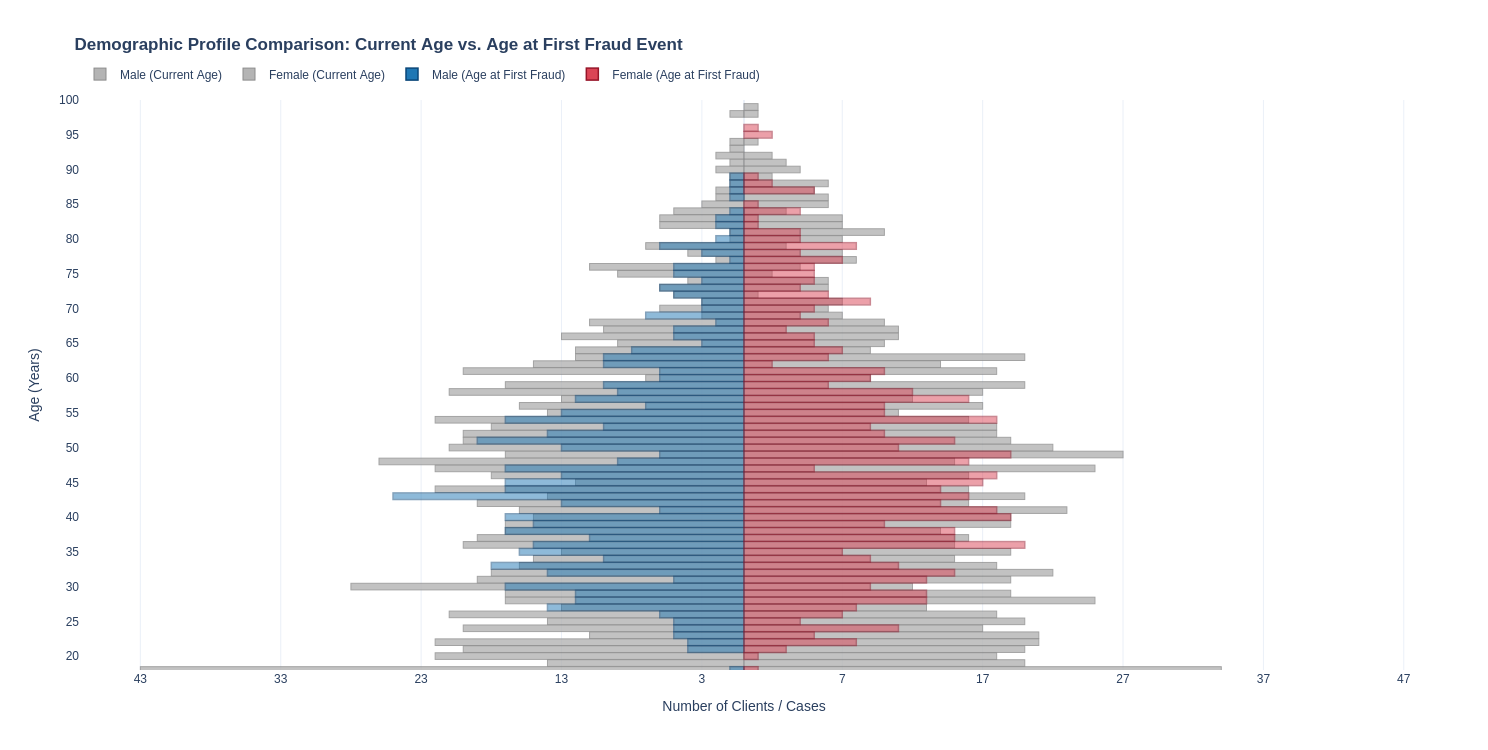

In [19]:
demographic_pd = demographic_df.toPandas()
males_gen = demographic_pd[demographic_pd["gender"] == "Male"]
females_gen = demographic_pd[demographic_pd["gender"] == "Female"]

demographic_first_fraud_age_pd = demographic_first_fraud_age_df.toPandas()
males_frd = demographic_first_fraud_age_pd[demographic_first_fraud_age_pd["gender"] == "Male"]
females_frd = demographic_first_fraud_age_pd[demographic_first_fraud_age_pd["gender"] == "Female"]


demographic_fig = go.Figure()

demographic_fig.add_trace(go.Bar(
    y=males_gen["current_age"],
    x=males_gen["count_pyramid"],
    name="Male (Current Age)",
    orientation="h",
    marker=dict(color="#B4B4B4", opacity=0.8, line=dict(color="#8C8C8C", width=1)),
    hovertemplate="<b>Age: %{y} years old</b><br>General Males: %{customdata:,}<extra></extra>",
    customdata=males_gen["count"]
))
demographic_fig.add_trace(go.Bar(
    y=females_gen["current_age"],
    x=females_gen["count_pyramid"],
    name="Female (Current Age)",
    orientation="h",
    marker=dict(color="#B4B4B4", opacity=0.8, line=dict(color="#8C8C8C", width=1)),
    hovertemplate="<b>Age: %{y} years old</b><br>General Females: %{x:,}<extra></extra>"
))

demographic_fig.add_trace(go.Bar(
    y=males_frd["age_at_first_fraud"],
    x=males_frd["count_pyramid"],
    name="Male (Age at First Fraud)",
    orientation="h",
    marker=dict(color="#1F77B4", opacity=0.5, line=dict(color="#0A4678", width=1.5)),
    hovertemplate="<b>Age: %{y} years old</b><br>Fraudulent Males: %{customdata:,}<extra></extra>",
    customdata=males_frd["count"]
))
demographic_fig.add_trace(go.Bar(
    y=females_frd["age_at_first_fraud"],
    x=females_frd["count_pyramid"],
    name="Female (Age at First Fraud)",
    orientation="h",
    marker=dict(color="#DB4455", opacity=0.5, line=dict(color="#961428", width=1.5)),
    hovertemplate="<b>Age: %{y} years old</b><br>Fraudulent Females: %{x:,}<extra></extra>"
))

max_count = int(max(demographic_pd["count"].max(), demographic_first_fraud_age_pd["count"].max()))
tick_step = max(1, max_count // 4)
tick_vals = list(range(-max_count - tick_step, max_count + tick_step, tick_step))
tick_text = [str(abs(v)) for v in tick_vals]

demographic_fig.update_layout(
    title="<b>Demographic Profile Comparison: Current Age vs. Age at First Fraud Event</b>",
    barmode="overlay",        
    bargap=0.05, height=750, width=950, autosize=False,    
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
    xaxis=dict(
        title="Number of Clients / Cases", 
        tickvals=tick_vals, ticktext=tick_text, range=[-max_count * 1.1, max_count * 1.1]
    ),
    yaxis=dict(title="Age (Years)", type="linear", range=[18, 100], dtick=5),
    template="plotly_white"
)

demographic_fig.show()

In [16]:
demographic_fraud_age_df = (
    fraud_data_df
    .filter(F.col("target") == True)
    .withColumn("age_at_transaction", F.year(F.col("date")) - F.col("birth_year"))
    .groupBy("age_at_transaction", "gender")
    .agg(F.count("target").alias("Total"))
    .withColumn("Total_pyramid", 
        F.when(F.col("gender") == "Male", F.col("Total") * -1).otherwise(F.col("Total"))
    )
)

demographic_fraud_age_df.show(5)

+------------------+------+-----+-------------+
|age_at_transaction|gender|Total|Total_pyramid|
+------------------+------+-----+-------------+
|                61|Female|  144|          144|
|                70|  Male|   57|          -57|
|                77|Female|  106|          106|
|                48|  Male|  132|         -132|
|                56|Female|  102|          102|
+------------------+------+-----+-------------+
only showing top 5 rows



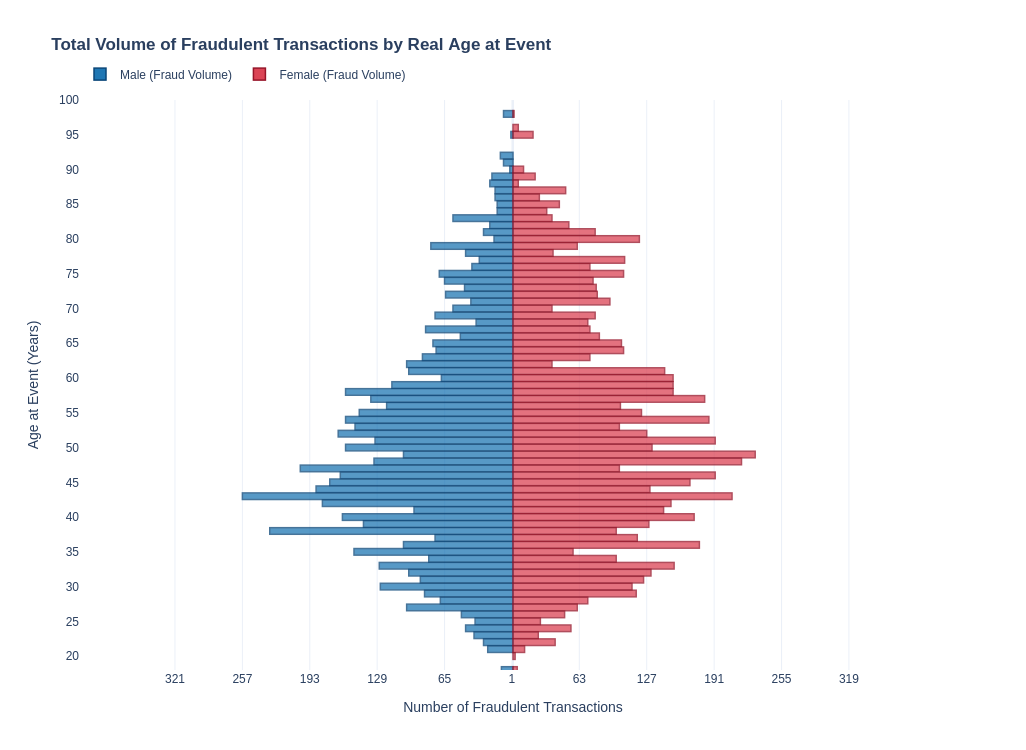

In [18]:
demographic_fraud_age_pd = demographic_fraud_age_df.toPandas()
males_frd2 = demographic_fraud_age_pd[demographic_fraud_age_pd["gender"] == "Male"]
females_frd2 = demographic_fraud_age_pd[demographic_fraud_age_pd["gender"] == "Female"]

demographic_fraud_age_fig = go.Figure()

demographic_fraud_age_fig.add_trace(go.Bar(
    y=males_frd2["age_at_transaction"],
    x=males_frd2["Total_pyramid"],
    name="Male (Fraud Volume)",
    orientation="h",
    marker=dict(color="#1F77B4", opacity=0.75, line=dict(color="#0A4678", width=1.5)),
    hovertemplate="<b>Age: %{y} years old</b><br>Fraudulent Transactions: %{customdata:,}\
    <extra></extra>",
    customdata=males_frd2["Total"]
))

demographic_fraud_age_fig.add_trace(go.Bar(
    y=females_frd2["age_at_transaction"],
    x=females_frd2["Total_pyramid"],
    name="Female (Fraud Volume)",
    orientation="h",
    marker=dict(color="#DB4455", opacity=0.75, line=dict(color="#961428", width=1.5)),
    hovertemplate="<b>Age: %{y} years old</b><br>Fraudulent Transactions: %{customdata:,}\
    <extra></extra>",
    customdata=females_frd2["Total"]
))

max_count = int(demographic_fraud_age_pd["Total"].max())
tick_step = max(1, max_count // 4)
tick_vals = list(range(-max_count - tick_step, max_count + tick_step, tick_step))
tick_text = [str(abs(v)) for v in tick_vals]

demographic_fraud_age_fig.update_layout(
    title="<b>Total Volume of Fraudulent Transactions by Real Age at Event</b>",
    barmode="overlay", bargap=0.05, height=750, width=950, autosize=False,    
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
    xaxis=dict(title="Number of Fraudulent Transactions", 
               tickvals=tick_vals, ticktext=tick_text, range=[-max_count * 1.6, max_count * 1.6]),
    yaxis=dict(title="Age at Event (Years)", type="linear", range=[18, 100], dtick=5),
    template="plotly_white",
)

demographic_fraud_age_fig.show()

In [40]:
demographic_transaction_age_df = (
    fraud_data_df
    .filter(F.col("target").isNotNull())
    .withColumn("age_at_event", F.year(F.col("date")) - F.col("birth_year"))
    .groupBy("age_at_event", "gender")
    .pivot("target", [False, True])
    .agg(F.count("target"))
    .na.fill(0)
    .withColumnRenamed("false", "Legitimate")
    .withColumnRenamed("true", "Fraudulent")
    .withColumn("frd_leg_ratio",  F.round(F.col("Fraudulent") / (F.col("Legitimate") + 1), 5))
    .withColumn("ratio_pyramid", 
        F.when(F.col("gender") == "Male", F.col("frd_leg_ratio") * -1)
         .otherwise(F.col("frd_leg_ratio"))
    )
    .orderBy(F.desc("Legitimate"))
)

demographic_transaction_age_df.show(5)


+------------+------+----------+----------+-------------+-------------+
|age_at_event|gender|Legitimate|Fraudulent|frd_leg_ratio|ratio_pyramid|
+------------+------+----------+----------+-------------+-------------+
|          43|Female|    125401|       208|      0.00166|      0.00166|
|          42|Female|    123841|       150|      0.00121|      0.00121|
|          47|  Male|    120651|       202|      0.00167|     -0.00167|
|          45|Female|    120650|       168|      0.00139|      0.00139|
|          46|  Male|    120584|       164|      0.00136|     -0.00136|
+------------+------+----------+----------+-------------+-------------+
only showing top 5 rows



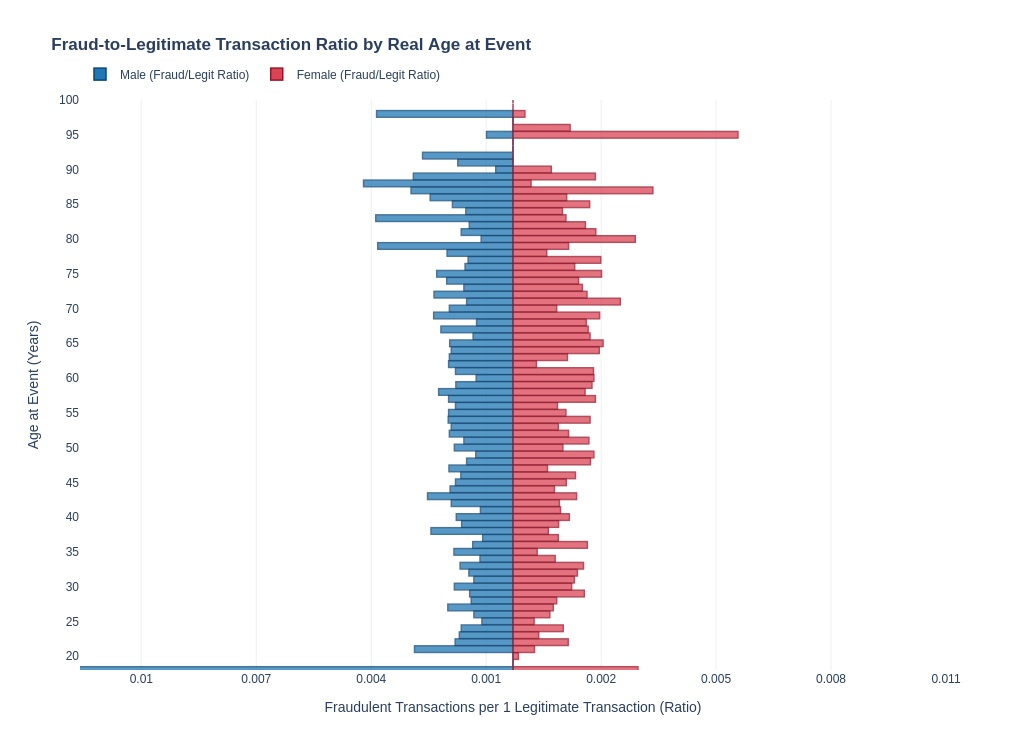

In [44]:
demographic_transaction_age_pd = demographic_transaction_age_df.toPandas()
males_ratio = demographic_transaction_age_pd[demographic_transaction_age_pd["gender"] == "Male"]
females_ratio = demographic_transaction_age_pd[demographic_transaction_age_pd["gender"] == "Female"]

demographic_transaction_age_fig = go.Figure()

demographic_transaction_age_fig.add_trace(go.Bar(
    y=males_ratio["age_at_event"],
    x=males_ratio["ratio_pyramid"],
    name="Male (Fraud/Legit Ratio)",
    orientation="h",
    marker=dict(color="#1F77B4", opacity=0.75, line=dict(color="#0A4678", width=1.5)),
    hovertemplate="<b>Age at Event: %{y} years old</b><br>" +
                  "Fraud Ratio: %{customdata[2]:.4f}<br>" +
                  "Fraudulent Transactions: %{customdata[1]:,}<br>" +
                  "Legitimate Transactions: %{customdata[0]:,}<extra></extra>",
    customdata=males_ratio[["Legitimate", "Fraudulent", "frd_leg_ratio"]].values
))
demographic_transaction_age_fig.add_trace(go.Bar(
    y=females_ratio["age_at_event"],
    x=females_ratio["ratio_pyramid"],
    name="Female (Fraud/Legit Ratio)",
    orientation="h",
    marker=dict(color="#DB4455", opacity=0.75, line=dict(color="#961428", width=1.5)),
    hovertemplate="<b>Age at Event: %{y} years old</b><br>" +
                  "Fraud Ratio: %{customdata[2]:.4f}<br>" +
                  "Fraudulent Transactions: %{customdata[1]:,}<br>" +
                  "Legitimate Transactions: %{customdata[0]:,}<extra></extra>",
    customdata=females_ratio[["Legitimate", "Fraudulent", "frd_leg_ratio"]].values
))

max_ratio = pd_fraud_ratio["frd_leg_ratio"].max()
tick_step = max(0.001, round(max_ratio / 4, 3))

tick_vals = []
val = -max_ratio
while val <= max_ratio:
    tick_vals.append(round(val, 4))
    val += tick_step
tick_text = [str(abs(round(v, 3))) for v in tick_vals]
limite_eje_x = abs(tick_vals[-1])


demographic_transaction_age_fig.update_layout(
    title="<b>Fraud-to-Legitimate Transaction Ratio by Real Age at Event</b>",
    barmode="overlay", bargap=0.05, height=750, width=950, autosize=False,    
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
    xaxis=dict(
        title="Fraudulent Transactions per 1 Legitimate Transaction (Ratio)", 
        tickvals=tick_vals, ticktext=tick_text, range=[-limite_eje_x, limite_eje_x]
    ),
    yaxis=dict(title="Age at Event (Years)", type="linear", range=[18, 100], dtick=5),
    template="plotly_white",
)

demographic_transaction_age_fig.show()


A continuación analizaremos el riesgo de fraude según el tipo de comercio

In [89]:
global_window = Window.rowsBetween(Window.unboundedPreceding, Window.unboundedFollowing)

mcc_description_df = (
    fraud_data_df
    .filter(F.col("target").isNotNull())
    .groupBy("mcc_description")
    .pivot("target", ["false", "true"])
    .agg(F.count("mcc_description"))
    .na.fill(0) 
    .withColumnRenamed("false", "Legitimate")
    .withColumnRenamed("true", "Fraudulent")
    .withColumns({
        "total_leg": F.sum("Legitimate").over(global_window),
        "total_fraud": F.sum("Fraudulent").over(global_window),
        "fraud_rate": F.col("total_fraud") / F.col("total_leg"),
        "mcc_rate": F.col("Fraudulent") / (F.col("Legitimate") + 1),
        "mcc_risk_factor": F.round((F.col("Fraudulent") / (F.col("Legitimate") + 1)) / (F.sum("Fraudulent").over(global_window) / F.sum("Legitimate").over(global_window)), 2),
        "Log2_risk_factor": F.round(F.log2((F.col("Fraudulent") / (F.col("Legitimate") + 1)) / (F.sum("Fraudulent").over(global_window) / F.sum("Legitimate").over(global_window)) + 0.00001), 2)
    })
    .withColumn(
        "mcc_risk_category",
        F.when(F.col("Log2_risk_factor") > 2, "High Risk")
         .when(F.col("Log2_risk_factor") < -2, "Low Risk")
         .otherwise("Baseline Risk")
    )
    .drop("total_leg", "total_fraud", "fraud_rate", "mcc_rate")
)

mcc_description_df.limit(5).toPandas()


,mcc_description,Legitimate,Fraudulent,mcc_risk_factor,Log2_risk_factor,mcc_risk_category
0,Cleaning and Maintenance Services,34211,4,0.08,-3.68,Low Risk
1,Floor Covering Stores,199,23,76.78,6.26,High Risk
2,Local and Suburban Commuter Transportation,56380,0,0.00,-16.61,Low Risk
3,"Grocery Stores, Supermarkets",1066408,425,0.27,-1.91,Baseline Risk
4,"Books, Periodicals, Newspapers",6908,0,0.00,-16.61,Low Risk


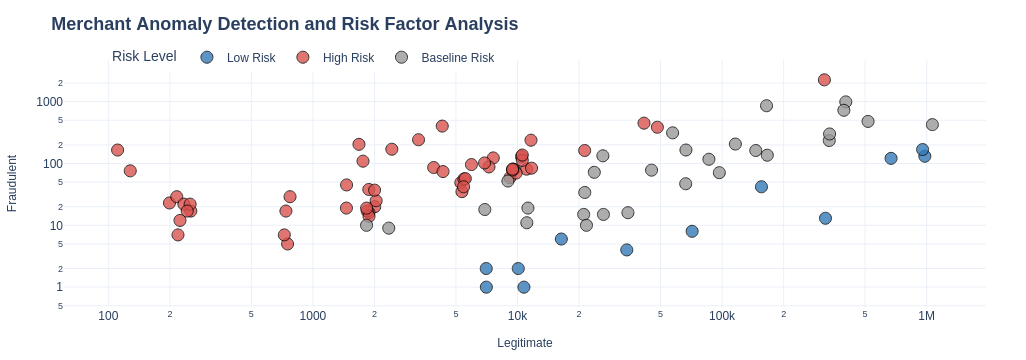

In [90]:
mcc_description_pd = mcc_description_df.toPandas()

color_risk = {
    'High Risk': '#d9534f',      
    'Baseline Risk': '#999999',  
    'Low Risk': '#337ab7'      
}

mcc_fig = px.scatter(
    mcc_description_pd,
    x="Legitimate",
    y="Fraudulent",
    color="mcc_risk_category",   
    color_discrete_map=color_risk,    
    hover_name="mcc_description", 
    hover_data=["Legitimate", "Fraudulent", "mcc_risk_factor", "Log2_risk_factor"],
    log_x=True,                   
    log_y=True,                  
    title="<b>Merchant Anomaly Detection and Risk Factor Analysis</b>",
    labels={"mcc_risk_category": "Risk Level", "mcc_risk_factor": "Risk Factor",
           "Log2_risk_factor": "Log2(Risk Factor)"},
    template="plotly_white"   
)


mcc_fig.update_traces(
    marker=dict(
        size=12,
        line=dict(width=1, color='Black'),
        opacity=0.8
    )
)

mcc_fig.update_layout(
    title_font_size=18,
    xaxis_title_font_size=12,
    yaxis_title_font_size=12,
    margin=dict(l=40, r=40, t=60, b=40),
    legend=dict(orientation="h", yanchor="top", y=1.07, xanchor="left", x=0.05)
)

mcc_fig.show()

El resto de variables, parámetros y tendencias las analizaremos en los siguientes notebooks titulados EDA